In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("placement.csv")

In [5]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'package')

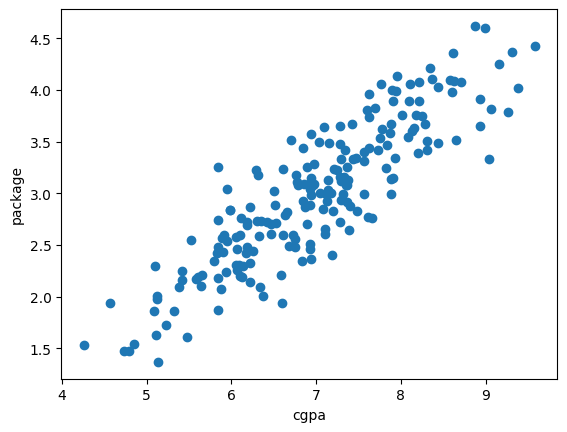

In [6]:
plt.scatter(df["cgpa"],df["package"])
plt.xlabel('cgpa')
plt.ylabel('package')

In [7]:
X = df.iloc[:,0:1]
Y = df.iloc[:,-1]

In [8]:
X

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [9]:
Y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
lr = LinearRegression()

In [14]:
lr.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
X_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [16]:
lr.predict(X_test.iloc[2].values.reshape(1,1))

C:\Users\ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.38464568])

Text(0, 0.5, 'package')

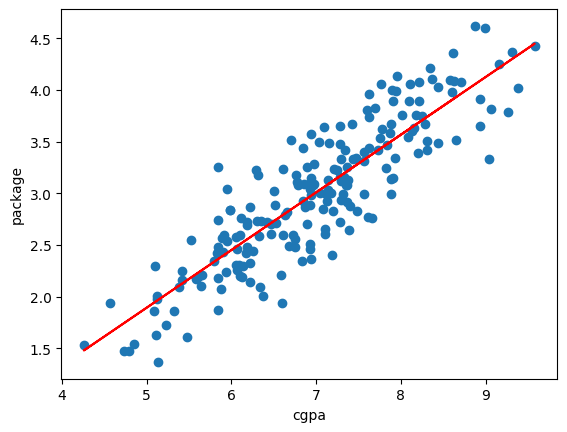

In [17]:
plt.scatter(df["cgpa"],df["package"])
plt.plot(X_train,lr.predict(X_train),color="r")
plt.xlabel('cgpa')
plt.ylabel('package')

In [18]:
m = lr.coef_

In [19]:
c = lr.intercept_

In [20]:
# y = mx + c
m*8.58 + c

array([3.89111601])

In [29]:
!pip install plotly


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\ayush\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [22]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go 

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [23]:
x,y = make_regression(n_samples=100,n_features=2,n_informative=2,n_targets=1,noise=50)

In [24]:
df = pd.DataFrame({
    "feature1":x[:,0],
    "feature2":x[:,1],
    "target":y
    })

In [25]:
df.head()

,feature1,feature2,target
0,-0.722994,0.853606,-0.101452
1,0.749176,1.115640,57.938787
2,0.318664,-0.198481,-48.022466
3,1.129909,-0.204861,127.121200
4,-0.100825,-1.197936,-8.324169


In [26]:
df.shape

(100, 3)

In [27]:
fig = px.scatter_3d(df,x="feature1",y="feature2",z="target")

In [28]:
fig.show()

In [37]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=.2,random_state=3)

In [38]:
from sklearn.linear_model import LinearRegression

In [39]:
lr = LinearRegression()

In [40]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
y_pred = lr.predict(x_test)
print(y_pred)

[  -6.49718697   -7.20186117   -2.18050349    2.8869632   -32.73923354
 -119.82373635   18.63363087  -29.27631802  108.45510371   45.05111577
 -174.94371828   60.17308275  -66.94466299   82.40641948  -90.52302448
  -49.87834367   75.70840758   -2.21733289  -71.75676664  106.9214332 ]


In [47]:
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 Score",r2_score(y_test,y_pred))

MAE 41.44380288307172
MSE 2715.2359363701144
R2 Score 0.7375241817094516


In [49]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)

xGrid, yGrid = np.meshgrid(y, x)
final = np.vstack((
    xGrid.ravel().reshape(1, 100),
    yGrid.ravel().reshape(1, 100)
)).T
z_final = lr.predict(final).reshape(10, 10)
z = z_final


In [51]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')
fig.add_trace(go.Surface(x=xGrid, y=yGrid, z=z))
